In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

In [29]:
df  = pd.read_csv('/content/NFLX.csv')
df

,Date,Open,High,Low,Close,Adj Close,Volume
0,2018-02-05,262.000000,267.899994,250.029999,254.259995,254.259995,11896100
1,2018-02-06,247.699997,266.700012,245.000000,265.720001,265.720001,12595800
2,2018-02-07,266.579987,272.450012,264.329987,264.559998,264.559998,8981500
3,2018-02-08,267.079987,267.619995,250.000000,250.100006,250.100006,9306700
4,2018-02-09,253.850006,255.800003,236.110001,249.470001,249.470001,16906900
...,...,...,...,...,...,...,...
1004,2022-01-31,401.970001,427.700012,398.200012,427.140015,427.140015,20047500
1005,2022-02-01,432.959991,458.480011,425.540009,457.130005,457.130005,22542300
1006,2022-02-02,448.250000,451.980011,426.480011,429.480011,429.480011,14346000
1007,2022-02-03,421.440002,429.260010,404.279999,405.600006,405.600006,9905200


In [30]:
df['Date'] = pd.to_datetime(df['Date'])

In [59]:
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Volume,0
smoothed_value,6


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1009 entries, 0 to 1008
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       1009 non-null   datetime64[ns]
 1   Open       1009 non-null   float64       
 2   High       1009 non-null   float64       
 3   Low        1009 non-null   float64       
 4   Close      1009 non-null   float64       
 5   Adj Close  1009 non-null   float64       
 6   Volume     1009 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 55.3 KB


In [32]:
df.describe()

,Date,Open,High,Low,Close,Adj Close,Volume
count,1009,1009.000000,1009.000000,1009.000000,1009.000000,1009.000000,1.009000e+03
mean,2020-02-05 07:30:58.870168320,419.059673,425.320703,412.374044,419.000733,419.000733,7.570685e+06
min,2018-02-05 00:00:00,233.919998,250.649994,231.229996,233.880005,233.880005,1.144000e+06
25%,2019-02-06 00:00:00,331.489990,336.299988,326.000000,331.619995,331.619995,4.091900e+06
50%,2020-02-06 00:00:00,377.769989,383.010010,370.880005,378.670013,378.670013,5.934500e+06
75%,2021-02-05 00:00:00,509.130005,515.630005,502.529999,509.079987,509.079987,9.322400e+06
max,2022-02-04 00:00:00,692.349976,700.989990,686.090027,691.690002,691.690002,5.890430e+07
std,NaN,108.537532,109.262960,107.555867,108.289999,108.289999,5.465535e+06


In [33]:
corr = df.corr(numeric_only=True)["Close"]
corr

,Close
Open,0.996812
High,0.998551
Low,0.998544
Close,1.000000
Adj Close,1.000000
Volume,-0.413362


In [34]:
# it means Adj Close and Close colums are same. it is not good for our model
df = df.drop(['Adj Close'], axis=1)

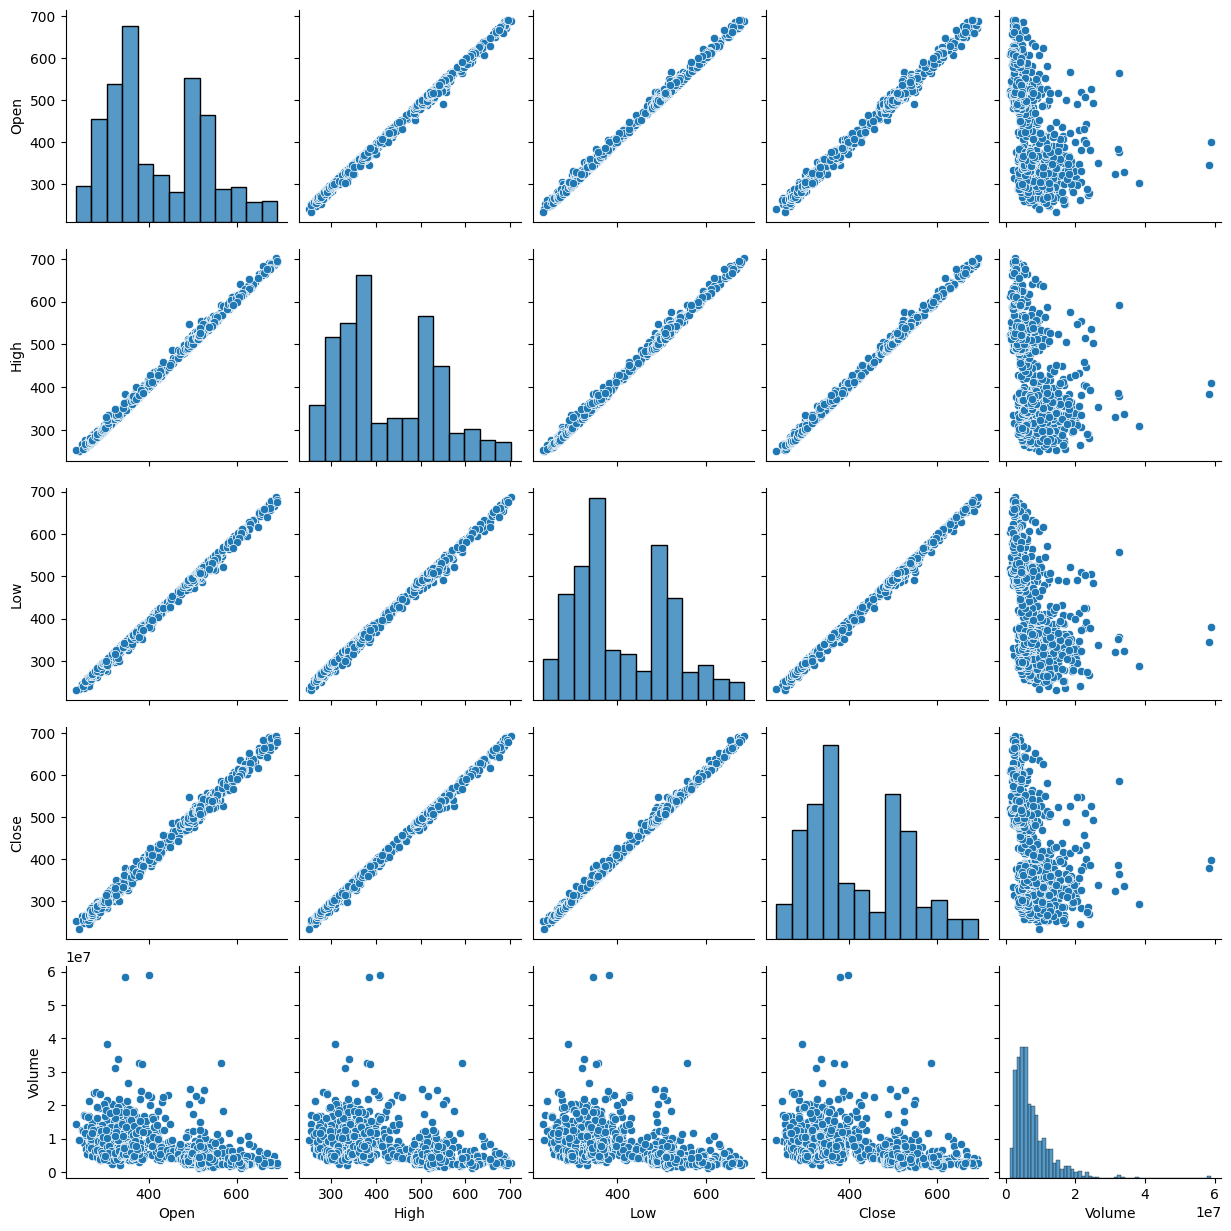

In [35]:
sns.pairplot(df)

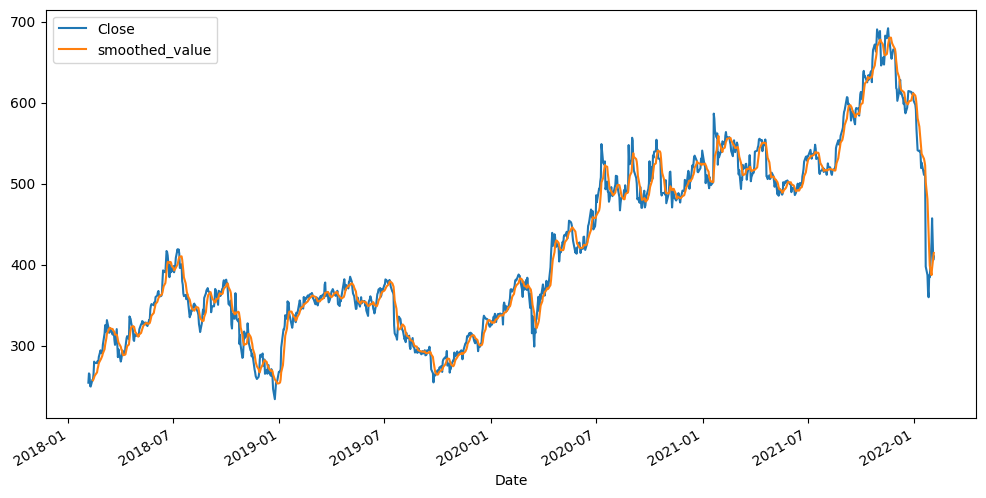

In [36]:
df['smoothed_value'] = df['Close'].rolling(window=7).mean()
df.plot(x='Date', y=['Close', 'smoothed_value'], figsize=(12, 6))
plt.show()

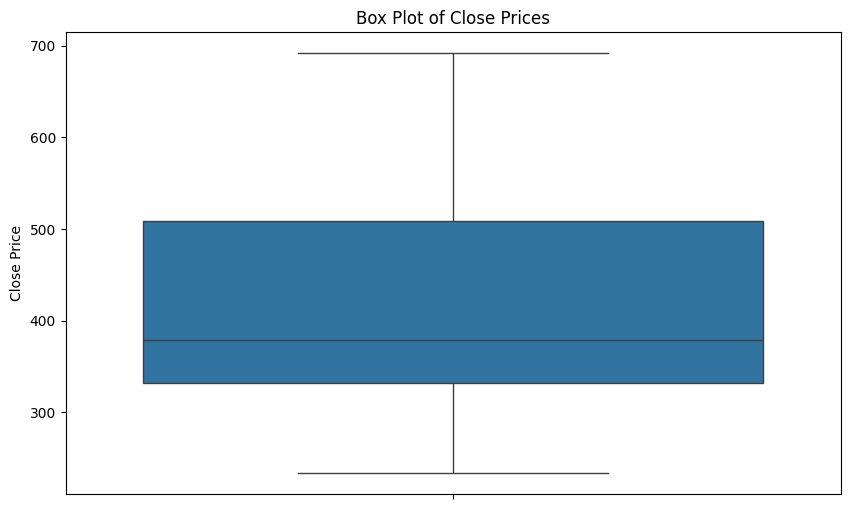

In [37]:
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['Close'])
plt.title('Box Plot of Close Prices')
plt.ylabel('Close Price')
plt.show()

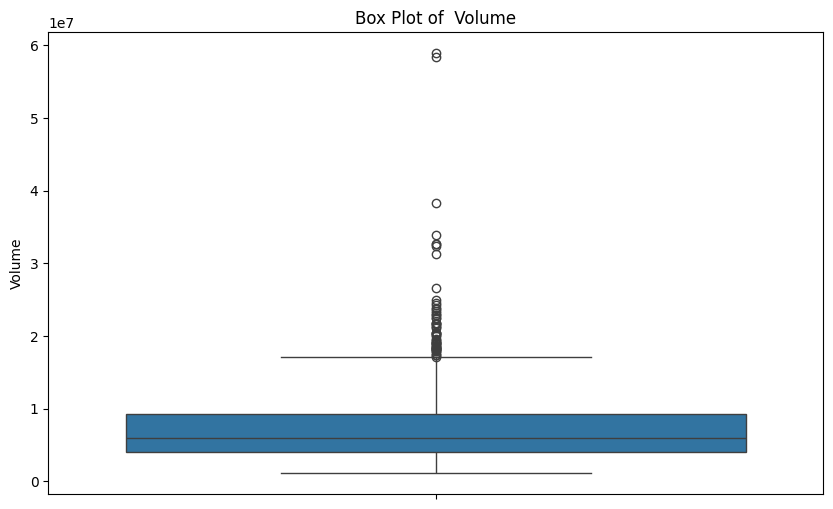

In [38]:
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['Volume'])
plt.title('Box Plot of  Volume')
plt.ylabel('Volume')
plt.show()

In [39]:
Q1 = df['Volume'].quantile(0.25)
Q3 = df['Volume'].quantile(0.75)
IQR = Q3 - Q1

outlier_lower_bound = Q1 - 1.5 * IQR
outlier_upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Volume'] < outlier_lower_bound) | (df['Volume'] > outlier_upper_bound)]

print(f"Number of detected outliers: {len(outliers)}")
print("Outlier data points:")
display(outliers)

Number of detected outliers: 57
Outlier data points:


,Date,Open,High,Low,Close,Volume,smoothed_value
19,2018-03-05,302.850006,316.910004,297.600006,315.000000,18986100,295.502856
20,2018-03-06,319.880005,325.790009,316.500000,325.220001,18525800,301.115714
24,2018-03-12,333.559998,333.980011,318.600006,321.299988,20369200,318.881426
36,2018-03-28,298.390015,298.799988,281.609985,285.769989,18972900,306.918575
37,2018-03-29,287.000000,295.350006,275.899994,295.350006,19145500,303.754290
48,2018-04-16,315.989990,316.100006,304.000000,307.779999,20307900,301.314287
49,2018-04-17,329.660004,338.619995,323.769989,336.059998,33866500,308.058572
89,2018-06-13,367.529999,384.250000,364.109985,379.929993,18222800,365.775713
95,2018-06-21,421.380005,423.209991,406.369995,415.440002,18389900,398.908574
97,2018-06-25,404.690002,405.989990,378.750000,384.480011,22490900,402.161434


In [40]:
df_cleaned = df.copy()
median_close = df_cleaned['Volume'].median()

df_cleaned.loc[(df_cleaned['Volume'] < outlier_lower_bound) | (df_cleaned['Volume'] > outlier_upper_bound), 'Volume'] = median_close

print("DataFrame after handling outliers:")
display(df_cleaned.head())

DataFrame after handling outliers:


,Date,Open,High,Low,Close,Volume,smoothed_value
0,2018-02-05,262.000000,267.899994,250.029999,254.259995,11896100,NaN
1,2018-02-06,247.699997,266.700012,245.000000,265.720001,12595800,NaN
2,2018-02-07,266.579987,272.450012,264.329987,264.559998,8981500,NaN
3,2018-02-08,267.079987,267.619995,250.000000,250.100006,9306700,NaN
4,2018-02-09,253.850006,255.800003,236.110001,249.470001,16906900,NaN


In [41]:
x = df.drop(['Date', 'Close'], axis=1)
y = df['Close']

In [42]:
# from pandas.core.arrays import categorical
numeric_features = x.select_dtypes(include=['int64', 'float64']).columns

In [43]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [66]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features)
    ])

In [67]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor(),
    "AdaBoost": AdaBoostRegressor(),
    "SVR": SVR()
}

In [63]:
Results = []

for name,regressor in models.items():
  model = Pipeline(steps=[('preprocessor', preprocessor),
                         ('regressor', regressor)])
  model.fit(x_train,y_train)
  y_pred = model.predict(x_test)
  mse = mean_squared_error(y_test, y_pred)
  r2 = r2_score(y_test, y_pred)

  Results.append({
        "Model": name,
        "MSE": mse,
        "R2": r2
    })


  print(f"\n{name}")
  print("MSE:", mse)
  print("R2:", r2)

results_df = pd.DataFrame(Results).sort_values("MSE")
print("\n📊 MODEL COMPARISON")
print(results_df)


Linear Regression
MSE: 16.019113674151452
R2: 0.9986261549760453

Decision Tree
MSE: 51.78721353609406
R2: 0.9955585803891359

Random Forest
MSE: 27.03787528461819
R2: 0.9976811544525077

Gradient Boosting
MSE: 26.39332136610282
R2: 0.9977364332408125

AdaBoost
MSE: 50.64722410585165
R2: 0.9956563491445088

SVR
MSE: 1631.264705278095
R2: 0.8600980713611286

📊 MODEL COMPARISON
               Model          MSE        R2
0  Linear Regression    16.019114  0.998626
3  Gradient Boosting    26.393321  0.997736
2      Random Forest    27.037875  0.997681
4           AdaBoost    50.647224  0.995656
1      Decision Tree    51.787214  0.995559
5                SVR  1631.264705  0.860098


In [73]:
from sklearn.model_selection import cross_val_score

# Find the dictionary with the minimum MSE
best_result_dict = min(Results, key=lambda x: x['MSE'])

# Extract the model name from this dictionary
best_model_name = best_result_dict['Model']

model = Pipeline([
      ('processing', preprocessor),
      ('regressor', models[best_model_name])
  ])

# Perform cross-validation for MSE
cv_mse = -cross_val_score(
    model,
    x_train,
    y_train,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
).mean()

# Perform cross-validation for R2 score
cv_r2 = cross_val_score(
    model,
    x_train,
    y_train,
    cv=5,
    scoring="r2",
    n_jobs=-1
).mean()
print(f'📊 The best model is {best_model_name} with CROSS-VALIDATION:')
print(f"MSE: {cv_mse:.4f}")
print(f"R² SCORE: {cv_r2:.4f}")

📊 The best model is Linear Regression with CROSS-VALIDATION:
MSE: 15.4306
R² SCORE: 0.9987
